# **MScFE 690: CapstoneProject**
## **Influence Diagram as A Decision-Making Tool for Factor Investing**
### Student Group: **11186**
#### Members:
1. **Vahid Nikoofard**
2. **Dipanshu Sharma**
3. **Rhesa Prabowo Budhidarmo**


In [ ]:
# installing the required packages

In [1]:
# importing the required packages and libraries

import io, os, sys, math, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings('ignore')

In [2]:
# master project path
# base_path = "/Users/sharmadipanshu/Developer/MScFE 2509 Capstone/WQU_Capstone_Project/MScFE_WQU_Capstone_Project"
base_path = '../'
# defining subpaths
inputs_raw = f"{base_path}/inputs/raw"
inputs_clean = f"{base_path}/inputs/clean"
outputs_eda = f"{base_path}/outputs/eda"
meta_path = f"{base_path}/inputs/meta"

In [3]:
# defining the required custom functions

## **Step 1: Exploratory Data Analysis (EDA) / ETL (Extract, Transfom and Load)**

In [4]:
# loading the MSCI Factor excel dataset

msci_path = f"{inputs_raw}/MSCI_Emerging_Markets_Factor_Index.xlsx"
msci_factor_data = pd.read_excel(msci_path, header=5, index_col= 0, usecols="A:F", parse_dates=True)
print("The Period of the dataset is from {} to {}".format(msci_factor_data.index.min().date(), msci_factor_data.index.max().date()))
msci_factor_data.columns = ['momentum', 'growth', 'value', 'quality', 'minimum_volatility']
display(msci_factor_data.head())

# resampling the dataset to monthly frequency = last observation of each month
msci_monthly_data = msci_factor_data.resample("M").last()

The Period of the dataset is from 2000-05-31 to 2025-09-12


,momentum,growth,value,quality,minimum_volatility
Date,,,,,
2000-05-31,1605.533518,107.225547,87.816374,257.737087,275.493383
2000-06-01,1627.767814,108.493933,88.338474,258.757821,275.824320
2000-06-02,1677.599646,112.769957,90.180719,268.084459,281.948828
2000-06-05,1687.410963,113.305427,91.153167,268.287892,283.679510
2000-06-06,1683.573275,112.498659,90.604808,266.346813,282.923252


In [5]:
# handling the missing returns
n_obs = len(msci_monthly_data)
missing_frac = msci_monthly_data.isna().sum() / n_obs
missing_report = pd.DataFrame({"n_missing": msci_monthly_data.isna().sum(),"missing_frac": missing_frac}).sort_values("missing_frac", ascending=False)
display(missing_report)

,n_missing,missing_frac
momentum,1,0.003279
growth,1,0.003279
value,1,0.003279
quality,1,0.003279
minimum_volatility,1,0.003279


In [6]:
# there is only one missing value in the dataset, using forward fill and backward fill method to impute it
msci_monthly_data = msci_monthly_data.ffill().bfill()

# calculating the monthly returns
msci_monthly_returns = msci_monthly_data.pct_change().dropna(how = 'any')
msci_monthly_returns.columns = [col + "_ret" for col in msci_monthly_returns.columns]
display(msci_monthly_returns.head())

# exported the cleaned dataset to the clean folder
msci_monthly_returns.to_csv(f"{inputs_clean}/msci_em_factor_monthly_returns.csv")

,momentum_ret,growth_ret,value_ret,quality_ret,minimum_volatility_ret
Date,,,,,
2000-06-30,0.010990,0.046680,0.020547,0.027184,0.023482
2000-07-31,-0.066766,-0.084035,-0.016382,-0.044815,-0.024922
2000-08-31,0.022835,0.013714,-0.005189,0.030152,-0.012023
2000-09-30,-0.101667,-0.088717,-0.085947,-0.076436,-0.049756
2000-10-31,-0.065633,-0.073891,-0.071061,-0.044771,-0.063982


### **Step 1.1- Summary Statistics and Distributions**

In [7]:
# summary statistics + higher moments
msci_returns_summary_stats = msci_monthly_returns.describe().T
msci_returns_summary_stats['skew'] = msci_monthly_returns.skew()
msci_returns_summary_stats['kurtosis'] = msci_monthly_returns.kurtosis()
msci_returns_summary_stats['n_obs'] = msci_monthly_returns.count()
msci_returns_summary_stats['n_nan'] = msci_monthly_returns.isna().sum()

# saving the summary stats
msci_returns_summary_stats.to_csv(os.path.join(outputs_eda, "msci_returns_summary_stats.csv"))

# display
display(msci_returns_summary_stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,n_obs,n_nan
momentum_ret,304.0,0.009541,0.062747,-0.248269,-0.024509,0.013225,0.051936,0.153438,-0.517298,1.042399,304,0
growth_ret,304.0,0.007416,0.061172,-0.276014,-0.025875,0.007555,0.047505,0.163168,-0.485446,1.382005,304,0
value_ret,304.0,0.008154,0.059276,-0.271224,-0.022856,0.008568,0.045140,0.179799,-0.356819,1.660964,304,0
quality_ret,304.0,0.008435,0.056072,-0.271266,-0.021210,0.009284,0.043682,0.174163,-0.529183,2.089155,304,0
minimum_volatility_ret,304.0,0.008358,0.045300,-0.221788,-0.016591,0.010955,0.036430,0.130229,-0.592636,2.127862,304,0


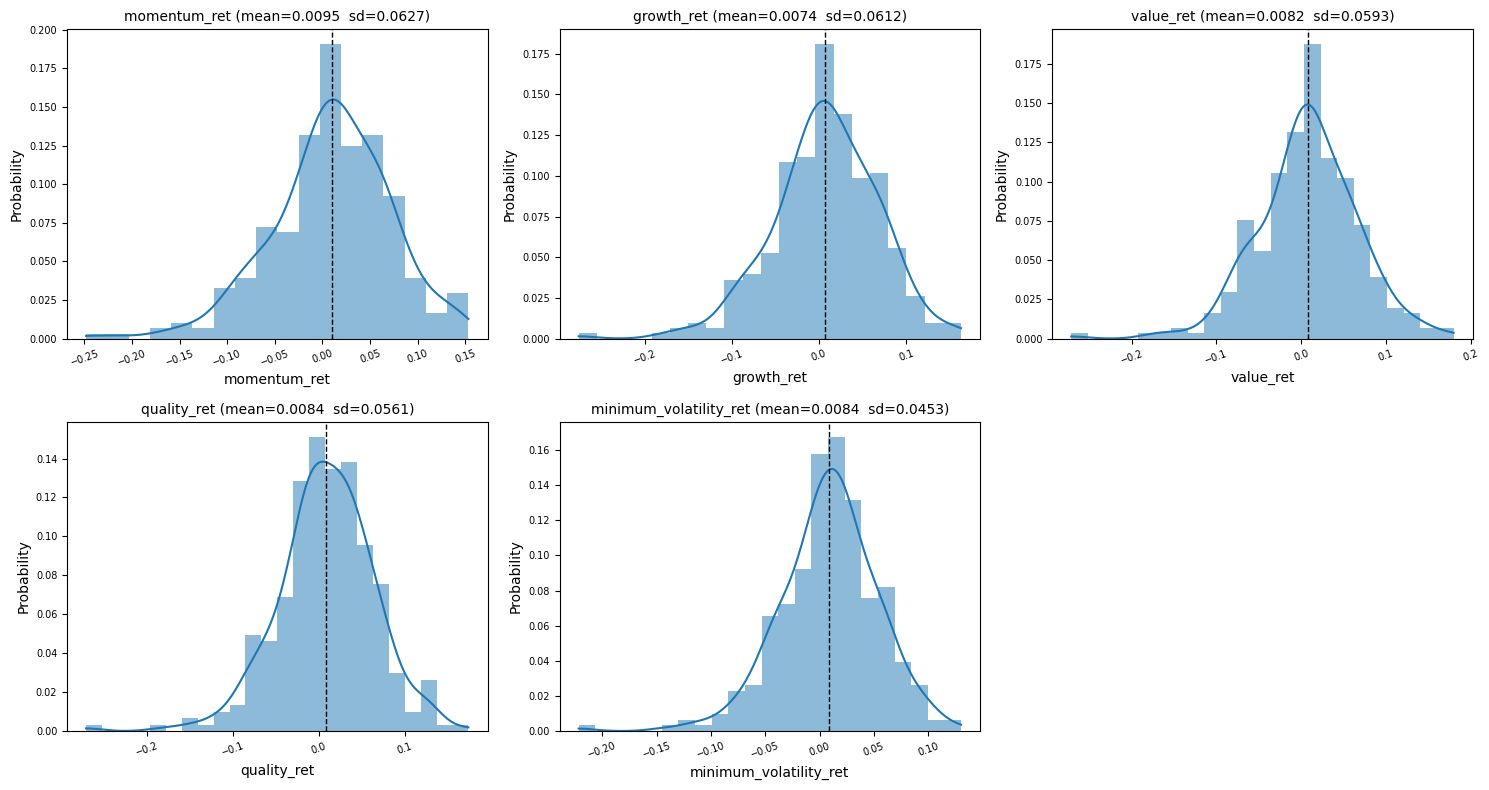

In [8]:
# plotting combined grid: histograms + KDE line for all factors monthly returns series
cols = msci_monthly_returns.columns.tolist()
n, ncols = len(cols), 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data = msci_monthly_returns[col].dropna()
    if len(data) == 0:
        ax.set_visible(False)
        continue
    sns.histplot(data, kde=True, ax=ax, stat="probability", edgecolor=None)
    ax.set_title(f"{col} (mean={data.mean():.4f}  sd={data.std():.4f})", fontsize=10)
    ax.axvline(data.mean(), color='k', linestyle='--', linewidth=1)
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(labelsize=7)

# turning off any extra axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
grid_png = os.path.join(outputs_eda, "msci_returns_distributions_grid.png")
fig.savefig(grid_png, dpi=300, bbox_inches='tight')
plt.show()

The MSCI Emerging Market factor returns exhibit average monthly returns of roughly $0.7\%–1.0\%$, with the momentum factor on the higher side. Volatility varies across factors, ranging from around $4.5\%$ for the minimum volatility index to $6.3\%$ for momentum. All factors show mild negative skewness and kurtosis greater than one, suggesting that the distributions are slightly left-skewed with fat tails relative to normal. This means that extreme negative returns, while rare, occur more frequently than a normal model would predict. Overall, the dataset is clean with no major missing values after preprocessing, and the distributions appear unimodal and fairly stable.

These statistical features imply several design choices for our modeling framework. For the Bayesian Network, it will be more robust to discretize returns into quantile bins (e.g., terciles) rather than equal-width bins. Since the distributions exhibit heavy tails, we should consider robust covariance estimation (e.g., Ledoit–Wolf shrinkage) when building the Influence Diagram optimizer. The lower dispersion of the minimum volatility factor suggests it may consistently receive higher weights in mean–variance optimization, which we’ll account for by adding weight caps and turnover penalties in the decision-making framework. Finally, the presence of fat tails and negative skew reinforces the value of including regime detection (e.g., HMM states) or downside-risk-aware utility functions as robustness checks later in the pipeline.

### **Step 1.2- Correlation Analysis**

### **Step 1.3- Time Series Plots**

### **Step 1.4- Autocorrelation**

### **Step 1.5- Information Coefficient (IC) and Stationarity Tests**